<a href="https://colab.research.google.com/github/JaswanthJavangula/ML_Practise/blob/main/1ML%20JAshu/PCA_CLUSTERINGs/PCA_PRAC_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

In [3]:
import kagglehub
import os
import pandas as pd

dipayanbiswas_parkinsons_disease_speech_signal_features_path = kagglehub.dataset_download('dipayanbiswas/parkinsons-disease-speech-signal-features')


file_path = os.path.join(dipayanbiswas_parkinsons_disease_speech_signal_features_path, 'pd_speech_features.csv')

df = pd.read_csv(file_path)
print('Data source import complete.')
df.head()

100%|██████████| 2.19M/2.19M [00:00<00:00, 40.4MB/s]

Extracting files...


Data source import complete.


,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [4]:
df_corr = df.corr()
df_corr

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
id,1.000000,-0.133605,0.026667,0.041938,-0.084606,0.085828,0.085226,-0.100831,-0.060464,-0.052865,...,0.036897,0.016047,-0.023317,-0.045943,-0.041835,-0.053781,-0.058034,-0.057807,-0.055775,-0.111661
gender,-0.133605,1.000000,0.010175,0.099356,0.168321,-0.478367,-0.477710,0.460422,-0.110587,0.112004,...,-0.098689,0.000210,0.066091,0.083499,0.089793,0.107618,0.128936,0.107734,0.104828,0.182713
PPE,0.026667,0.010175,1.000000,-0.094775,-0.405558,0.191535,0.194098,-0.201907,-0.423660,-0.349053,...,0.144261,0.135544,0.091726,0.065035,0.044163,0.045755,0.046175,0.037385,0.039588,-0.072939
DFA,0.041938,0.099356,-0.094775,1.000000,0.155075,-0.286791,-0.286611,0.253708,0.084655,0.212120,...,-0.146325,-0.104456,-0.061129,-0.063451,-0.061845,-0.033914,0.043454,0.067843,0.116699,0.306070
RPDE,-0.084606,0.168321,-0.405558,0.155075,1.000000,-0.521193,-0.524839,0.506707,0.333545,0.614340,...,-0.315592,-0.278504,-0.148989,-0.101467,-0.098923,-0.097161,-0.036406,-0.018052,0.021945,0.247444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tqwt_kurtosisValue_dec_33,-0.053781,0.107618,0.045755,-0.033914,-0.097161,-0.047946,-0.047837,0.039487,-0.092429,0.018504,...,0.239203,0.486570,0.708646,0.841365,0.945107,1.000000,0.824620,0.698738,0.543845,0.119808
tqwt_kurtosisValue_dec_34,-0.058034,0.128936,0.046175,0.043454,-0.036406,-0.068664,-0.068561,0.046140,-0.061721,0.027886,...,0.139668,0.383328,0.587449,0.667325,0.729501,0.824620,1.000000,0.948008,0.785141,0.192345
tqwt_kurtosisValue_dec_35,-0.057807,0.107734,0.037385,0.067843,-0.018052,-0.069645,-0.069468,0.040828,-0.067636,0.010553,...,0.054510,0.275390,0.477147,0.550686,0.609663,0.698738,0.948008,1.000000,0.866696,0.219454
tqwt_kurtosisValue_dec_36,-0.055775,0.104828,0.039588,0.116699,0.021945,-0.062925,-0.062790,0.031685,-0.067147,0.003805,...,-0.108280,0.070046,0.290106,0.386061,0.467944,0.543845,0.785141,0.866696,1.000000,0.279827


In [5]:
X= df.iloc[:,0:754].values
y = df.iloc[:,754].values
X.shape,y.shape

((756, 754), (756,))

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [7]:
#SCALING
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [8]:
#INTIALLIZING PCA
pc = PCA(n_components=None)
X_pca = pc.fit_transform(X_scaled)

In [9]:
EVALs= pc.explained_variance_
var = pc.explained_variance_ratio_
cum_ratio = np.cumsum(var)
print(len(EVALs))
print(var[:5])
print(cum_ratio[:5])

754
[0.12945498 0.09377605 0.08241923 0.04285396 0.03563514]
[0.12945498 0.22323103 0.30565026 0.34850422 0.38413936]


In [10]:
# FIND OUT - K - VALUE
target_variance = 0.90

for k , cr in enumerate(cum_ratio , start=1):
  if cr >= target_variance:
    print("smallest k with >= 90% var" , k)
    break
#Reffiting WITH K
pca_k = PCA(n_components=k,random_state=42)
X_pca = pca_k.fit_transform(X_scaled)
X_pca.shape

smallest k with >= 90% var 117


(756, 117)

In [11]:
#LOGISTIC REGRESSION COMPARISION OF OG DATA
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)
lr = LogisticRegression(max_iter=100).fit(X_train,y_train)
scoring_lr = lr.score(X_test,y_test)
print("Original Score :", scoring_lr)

Original Score : 0.868421052631579


In [12]:
#LOGISTIC REGRESSION COMPARISION OF PCA DATA
X_train_pca,X_test_pca,y_train_pca,y_test_pca = train_test_split(X_pca,y,test_size=0.2,random_state=42)
lr_pca = LogisticRegression(max_iter=100).fit(X_train_pca,y_train_pca)
scoring_lr_pca = lr_pca.score(X_test_pca,y_test_pca)
print("PCA Score :", scoring_lr_pca)

PCA Score : 0.8355263157894737


In [13]:
components = pca_k.components_
pca1 = components[0]
pca2 = components[1]

fi_pc1= list(zip(df.columns[0:754],pca1))
fi_pc2= list(zip(df.columns[0:754],pca2))

fi_pc1_sorted= sorted(fi_pc1,key=lambda x:abs(x[1]),reverse = True)
fi_pc2_sorted= sorted(fi_pc2,key=lambda x:abs(x[1]),reverse = True)

print("Top Features of PC1 :", fi_pc1_sorted[:5])
print("Top Features of PC2 :", fi_pc2_sorted[:5])

Top Features of PC1 : [('app_LT_entropy_shannon_6_coef', np.float64(0.08196663012131906)), ('app_LT_entropy_shannon_5_coef', np.float64(0.08195024157030321)), ('app_LT_TKEO_mean_10_coef', np.float64(-0.0818957752084526)), ('app_LT_entropy_shannon_7_coef', np.float64(0.08188414865122655)), ('app_LT_TKEO_std_10_coef', np.float64(-0.08187695570933931))]
Top Features of PC2 : [('tqwt_entropy_log_dec_26', np.float64(0.07259683569808234)), ('tqwt_entropy_log_dec_25', np.float64(0.07199409470377377)), ('tqwt_maxValue_dec_8', np.float64(0.07198586426591481)), ('tqwt_maxValue_dec_19', np.float64(0.0719841868236101)), ('tqwt_minValue_dec_19', np.float64(-0.07195365295033462))]


In [29]:
pca_k

PCA(n_components=117, random_state=42)

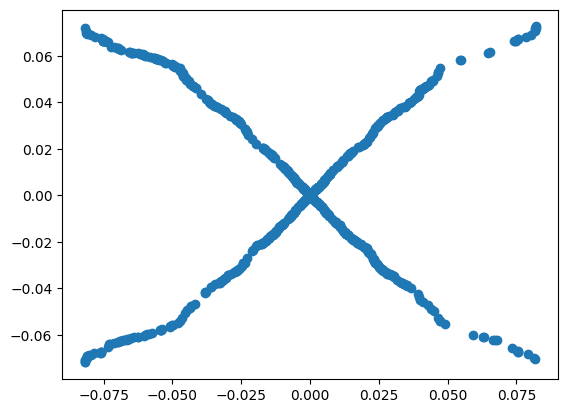

In [20]:
x_values = [item[1] for item in fi_pc1_sorted]
y_values = [item[1] for item in fi_pc2_sorted]
plt.scatter(x_values, y_values)

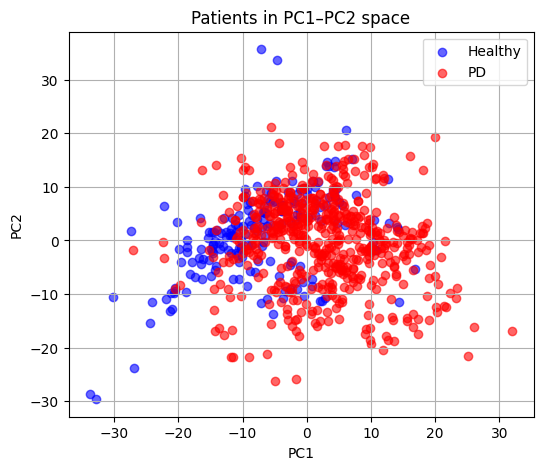

In [27]:
import matplotlib.pyplot as plt
X_scores = pca_k.transform(X_scaled)
pca1_scores = X_scores[:,0]
pca2_scores = X_scores[:,1]

# create mask for labels
mask_pd = (y == 1)          # PD patients
mask_healthy = (y == 0)     # healthy controls

plt.figure(figsize=(6, 5))

plt.scatter(pca1_scores[mask_healthy], pca2_scores[mask_healthy],
            alpha=0.6, label="Healthy", c="blue")
plt.scatter(pca1_scores[mask_pd], pca2_scores[mask_pd],
            alpha=0.6, label="PD", c="red")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Patients in PC1–PC2 space")
plt.grid(True)
plt.show()

In [37]:
pd.DataFrame(mask_healthy).value_counts()

,count
0,
False,564
True,192
